In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

papers = pd.read_csv("paper_table_full_rich.csv")
cites = pd.read_csv("citation_fk_rich.csv")

# Basic cleanup
papers["year"] = pd.to_numeric(papers["year"], errors="coerce")

# Keep only rows with usable ids
papers = papers.dropna(subset=["paper_id"])
papers["paper_id"] = papers["paper_id"].astype(int)

cites = cites.dropna(subset=["source_paper_id", "target_paper_id"])
cites["source_paper_id"] = cites["source_paper_id"].astype(int)
cites["target_paper_id"] = cites["target_paper_id"].astype(int)

/var/folders/rx/ln31tkt933s4gjs2g01hxj200000gn/T/ipykernel_32635/1531007503.py:5: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  papers = pd.read_csv("paper_table_full_rich.csv")


1. Papers per year

This shows whether your corpus is itself changing sharply over time.

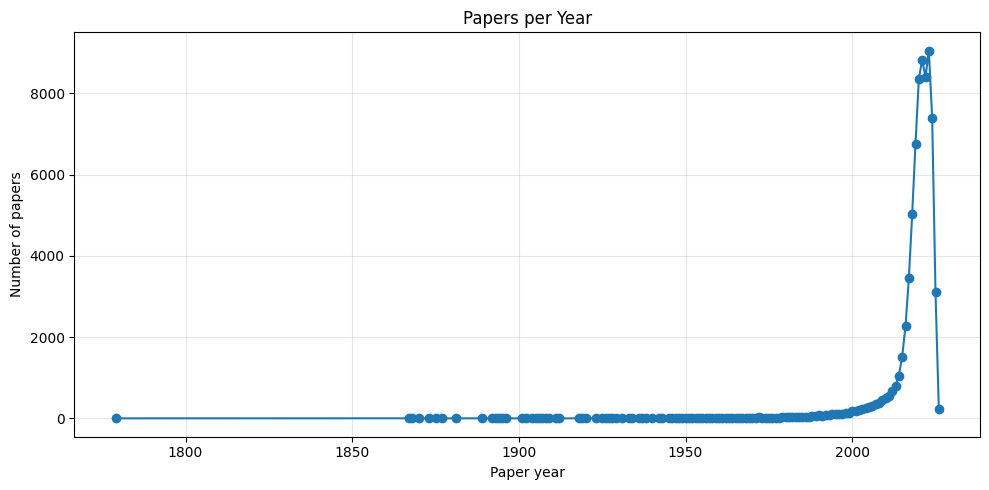

In [5]:
papers_per_year = (
    papers.dropna(subset=["year"])
          .groupby("year")
          .size()
          .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(papers_per_year.index, papers_per_year.values, marker="o")
plt.xlabel("Paper year")
plt.ylabel("Number of papers")
plt.title("Papers per Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2. Average references per paper by year

This is one of the most important plots if you want to ask whether newer papers are citing more or less.

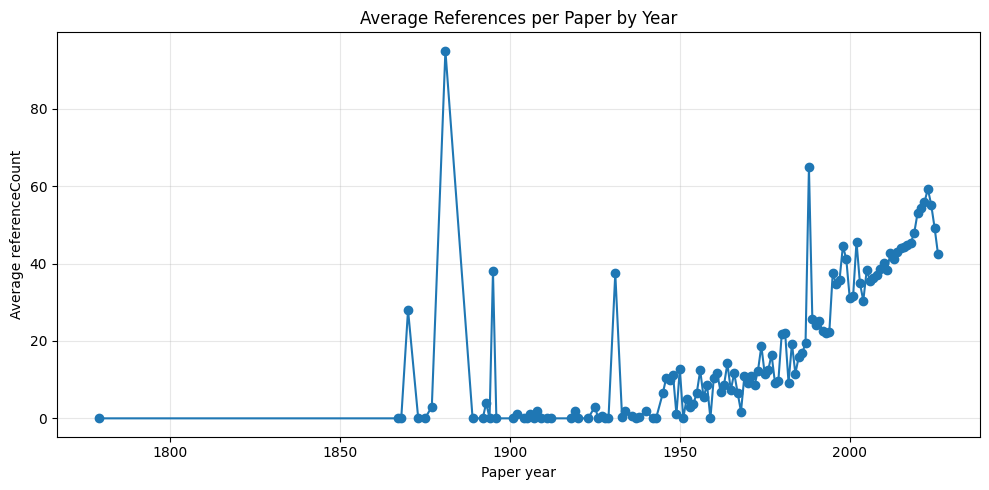

In [6]:
ref_by_year = (
    papers.dropna(subset=["year"])
          .groupby("year")["referenceCount"]
          .mean()
          .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(ref_by_year.index, ref_by_year.values, marker="o")
plt.xlabel("Paper year")
plt.ylabel("Average referenceCount")
plt.title("Average References per Paper by Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

If you want median too:

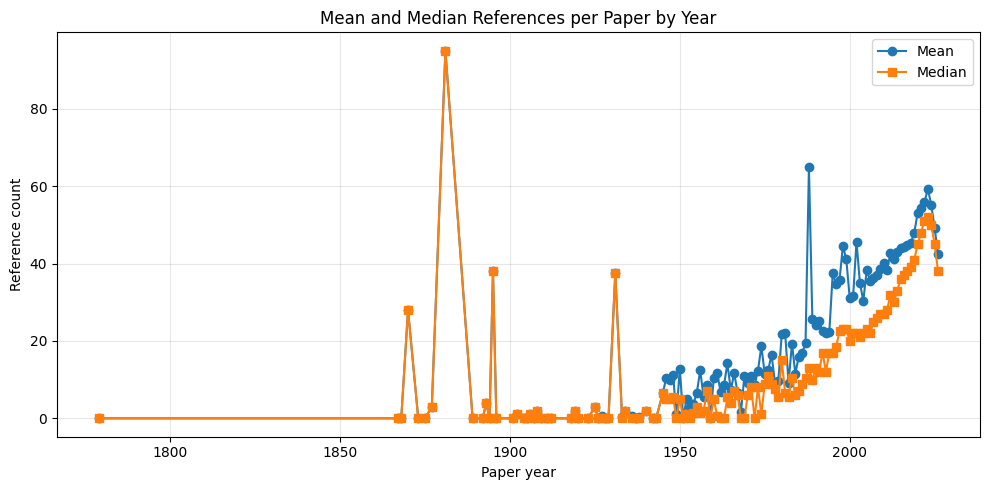

In [7]:
median_ref_by_year = (
    papers.dropna(subset=["year"])
          .groupby("year")["referenceCount"]
          .median()
          .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(ref_by_year.index, ref_by_year.values, marker="o", label="Mean")
plt.plot(median_ref_by_year.index, median_ref_by_year.values, marker="s", label="Median")
plt.xlabel("Paper year")
plt.ylabel("Reference count")
plt.title("Mean and Median References per Paper by Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

3. Build citation table with source year and target year

You need this merged table for several downstream plots.

In [8]:
paper_years = papers[["paper_id", "year"]].rename(columns={"paper_id": "id"})

citation_years = (
    cites.merge(
        paper_years.rename(columns={"id": "source_paper_id", "year": "source_year"}),
        on="source_paper_id",
        how="left"
    )
    .merge(
        paper_years.rename(columns={"id": "target_paper_id", "year": "target_year"}),
        on="target_paper_id",
        how="left"
    )
)

citation_years["age_gap"] = citation_years["source_year"] - citation_years["target_year"]

# Keep sensible rows only
citation_years_clean = citation_years[
    citation_years["source_year"].notna() &
    citation_years["target_year"].notna() &
    (citation_years["age_gap"] >= 0)
].copy()

4. Mean cited-paper age by source year

This is a core plot for your “older-paper concentration” question.

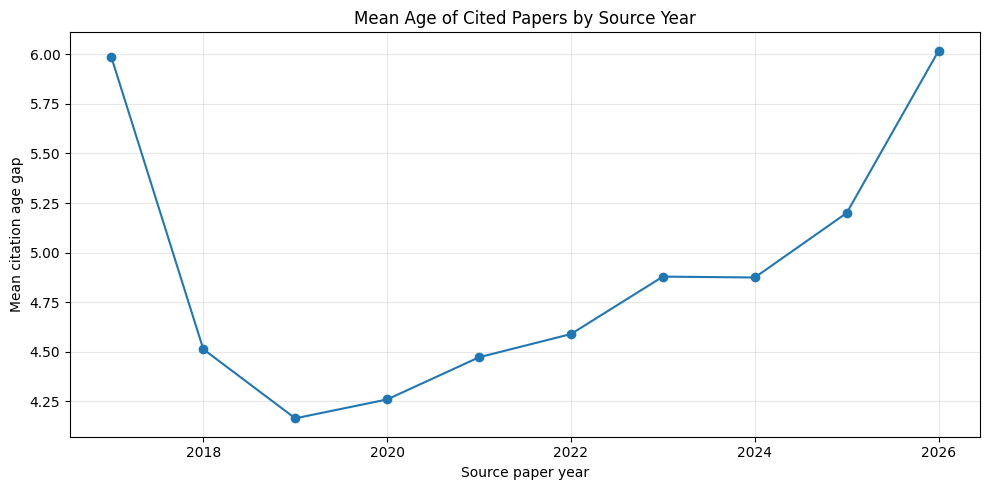

In [9]:
mean_age_by_source_year = (
    citation_years_clean.groupby("source_year")["age_gap"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(mean_age_by_source_year.index, mean_age_by_source_year.values, marker="o")
plt.xlabel("Source paper year")
plt.ylabel("Mean citation age gap")
plt.title("Mean Age of Cited Papers by Source Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Median version:

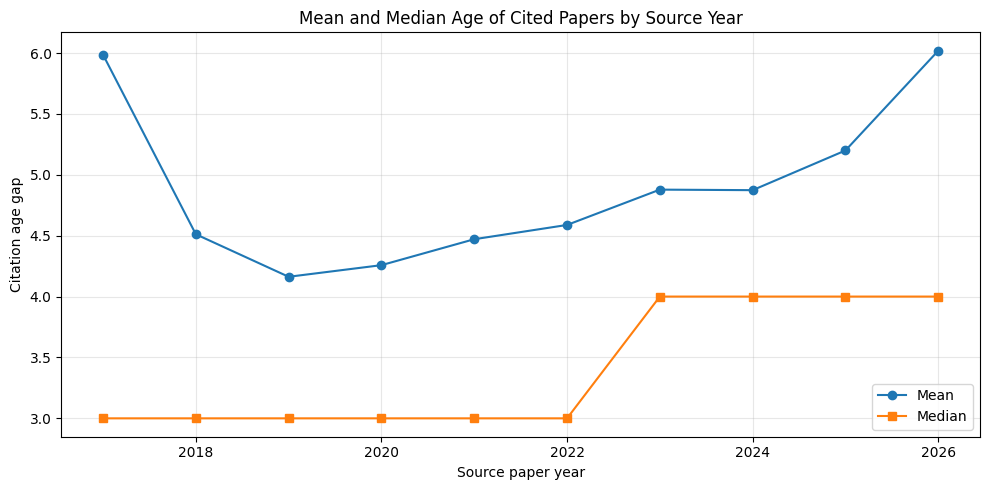

In [10]:
median_age_by_source_year = (
    citation_years_clean.groupby("source_year")["age_gap"]
    .median()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(mean_age_by_source_year.index, mean_age_by_source_year.values, marker="o", label="Mean")
plt.plot(median_age_by_source_year.index, median_age_by_source_year.values, marker="s", label="Median")
plt.xlabel("Source paper year")
plt.ylabel("Citation age gap")
plt.title("Mean and Median Age of Cited Papers by Source Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

5. Distribution of citation ages: pre-2023 vs post-2023

This is a direct comparison plot for your hypothesis.

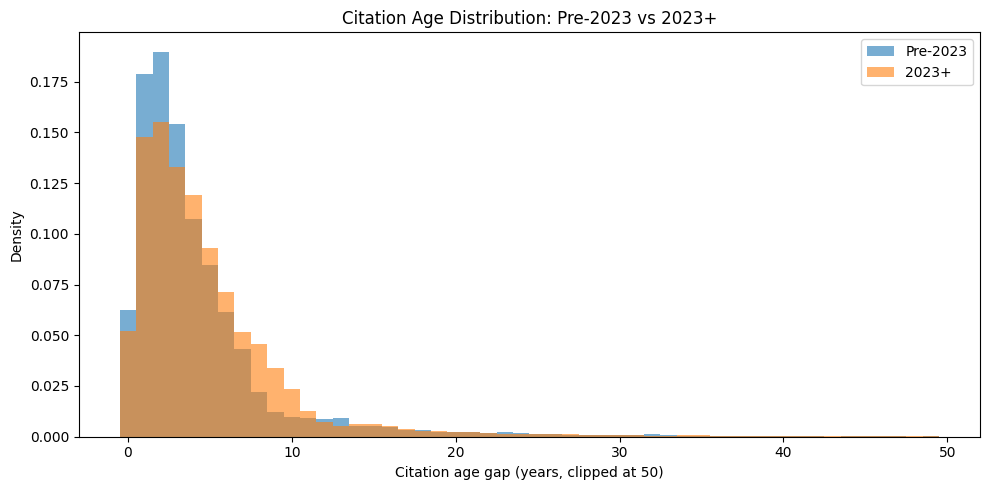

In [11]:
pre = citation_years_clean[citation_years_clean["source_year"] < 2023]["age_gap"]
post = citation_years_clean[citation_years_clean["source_year"] >= 2023]["age_gap"]

plt.figure(figsize=(10, 5))
bins = np.arange(0, min(51, int(citation_years_clean["age_gap"].max()) + 2)) - 0.5

plt.hist(pre.clip(upper=50), bins=bins, alpha=0.6, density=True, label="Pre-2023")
plt.hist(post.clip(upper=50), bins=bins, alpha=0.6, density=True, label="2023+")
plt.xlabel("Citation age gap (years, clipped at 50)")
plt.ylabel("Density")
plt.title("Citation Age Distribution: Pre-2023 vs 2023+")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
from scipy.stats import mannwhitneyu, ks_2samp

pre_clean = pre.dropna()
post_clean = post.dropna()

mw_u, mw_p = mannwhitneyu(pre_clean, post_clean, alternative="two-sided", method="auto")
ks_d, ks_p = ks_2samp(pre_clean, post_clean, alternative="two-sided", method="auto")

print(f"Mann–Whitney U test: U={mw_u:.3f}, p-value={mw_p:.6e}")
print(f"Kolmogorov–Smirnov test: D={ks_d:.3f}, p-value={ks_p:.6e}")


Mann–Whitney U test: U=4000037522.500, p-value=0.000000e+00
Kolmogorov–Smirnov test: D=0.097, p-value=0.000000e+00


A cleaner cumulative version:

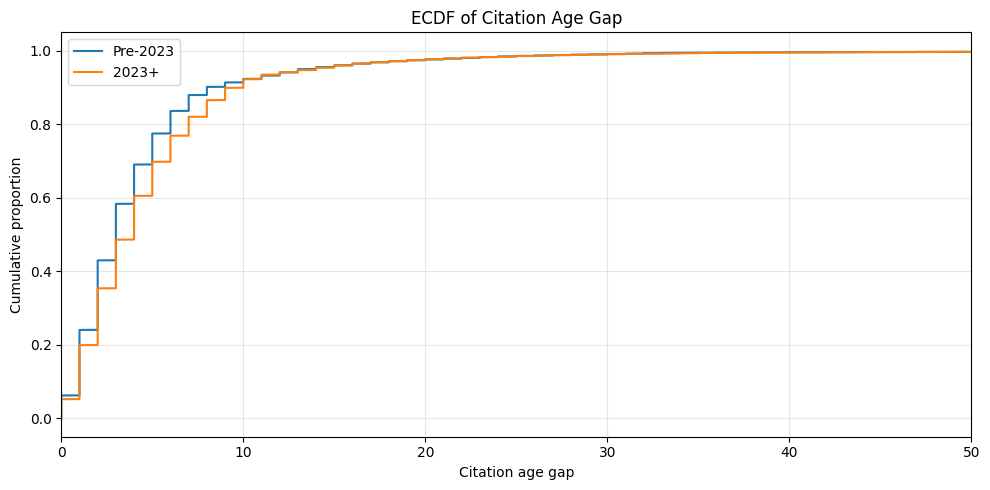

In [11]:
def ecdf(x):
    x = np.sort(x.dropna().values)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x1, y1 = ecdf(pre)
x2, y2 = ecdf(post)

plt.figure(figsize=(10, 5))
plt.plot(x1, y1, label="Pre-2023")
plt.plot(x2, y2, label="2023+")
plt.xlim(0, 50)
plt.xlabel("Citation age gap")
plt.ylabel("Cumulative proportion")
plt.title("ECDF of Citation Age Gap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

6. Share of citations going to “old” papers by source year

This is often more interpretable than mean age gap.

Example thresholds: cited paper is at least 5 years older or 10 years older.

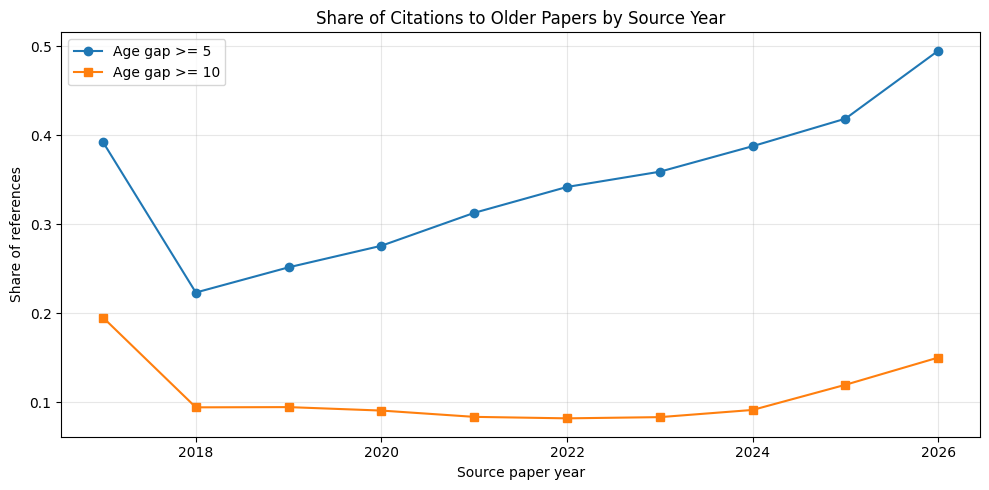

In [12]:
citation_years_clean["old_5"] = citation_years_clean["age_gap"] >= 5
citation_years_clean["old_10"] = citation_years_clean["age_gap"] >= 10

old_share_by_year = (
    citation_years_clean.groupby("source_year")[["old_5", "old_10"]]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(old_share_by_year.index, old_share_by_year["old_5"], marker="o", label="Age gap >= 5")
plt.plot(old_share_by_year.index, old_share_by_year["old_10"], marker="s", label="Age gap >= 10")
plt.xlabel("Source paper year")
plt.ylabel("Share of references")
plt.title("Share of Citations to Older Papers by Source Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

7. Top cited target papers within your corpus

This shows whether a few papers dominate the citation flow.

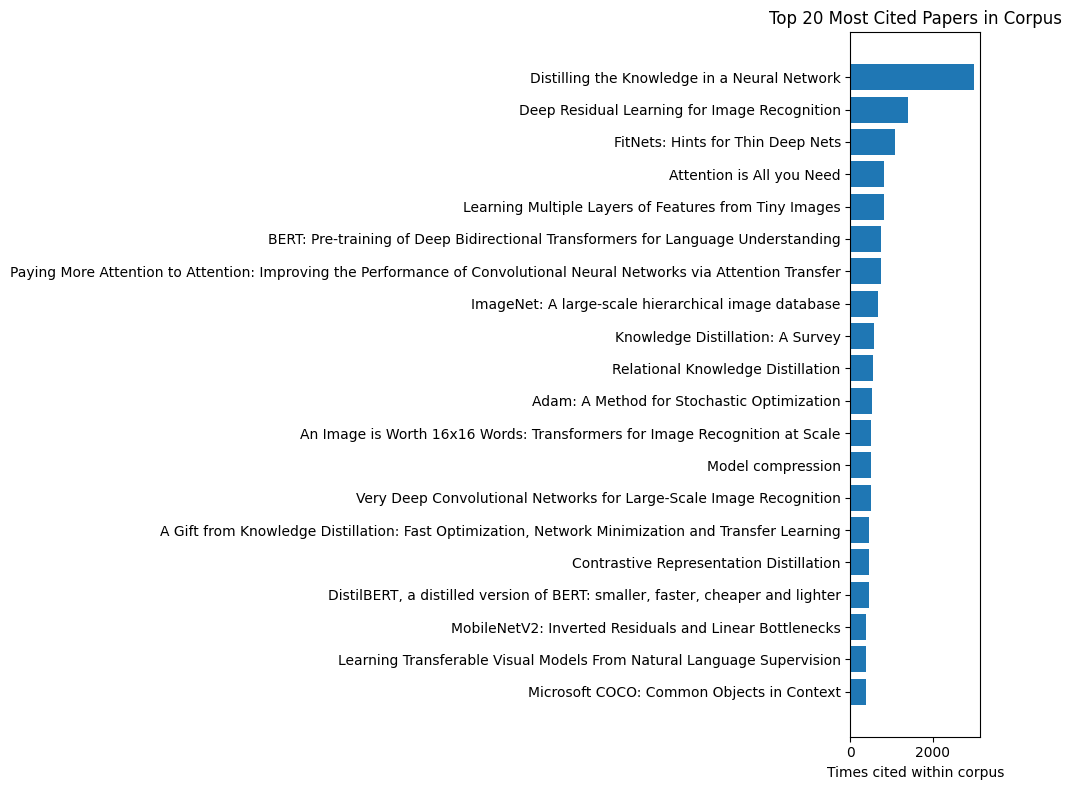

      target_paper_id                                              title  \
2033             4620       Distilling the Knowledge in a Neural Network   
2247             4834       Deep Residual Learning for Image Recognition   
1937             4524                  FitNets: Hints for Thin Deep Nets   
2066             4653                          Attention is All you Need   
2396             4983  Learning Multiple Layers of Features from Tiny...   
2074             4661  BERT: Pre-training of Deep Bidirectional Trans...   
2244             4831  Paying More Attention to Attention: Improving ...   
2252             4839  ImageNet: A large-scale hierarchical image dat...   
1661             4170                   Knowledge Distillation: A Survey   
1859             4420                  Relational Knowledge Distillation   
2034             4621         Adam: A Method for Stochastic Optimization   
2104             4691  An Image is Worth 16x16 Words: Transformers fo...   
2253        

In [13]:
in_degree = (
    cites.groupby("target_paper_id")
    .size()
    .reset_index(name="times_cited_in_corpus")
)

top_cited = (
    in_degree.merge(
        papers[["paper_id", "title", "year"]],
        left_on="target_paper_id",
        right_on="paper_id",
        how="left"
    )
    .sort_values("times_cited_in_corpus", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))
plt.barh(top_cited["title"].fillna(top_cited["target_paper_id"].astype(str))[::-1],
         top_cited["times_cited_in_corpus"][::-1])
plt.xlabel("Times cited within corpus")
plt.title("Top 20 Most Cited Papers in Corpus")
plt.tight_layout()
plt.show()

print(top_cited[["target_paper_id", "title", "year", "times_cited_in_corpus"]])

8. Citation concentration curve

This checks whether citations are becoming more concentrated among fewer papers.

Version A: Lorenz-style curve for all targets

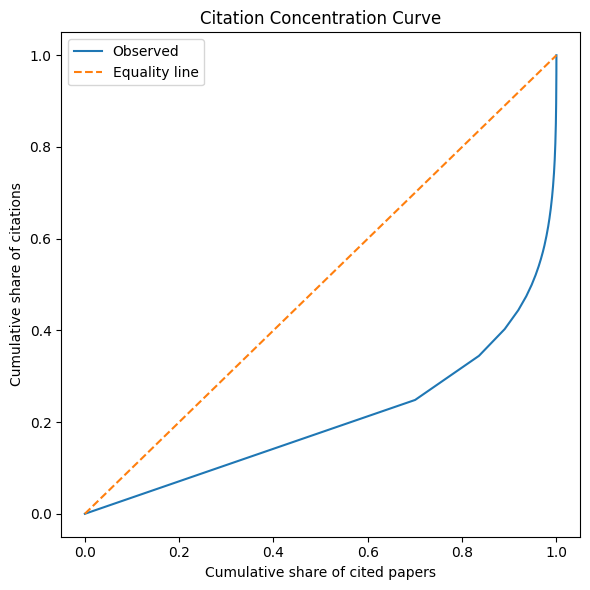

In [14]:
target_counts = (
    cites.groupby("target_paper_id")
    .size()
    .sort_values()
    .values
)

cum_targets = np.arange(1, len(target_counts) + 1) / len(target_counts)
cum_citations = np.cumsum(target_counts) / np.sum(target_counts)

plt.figure(figsize=(6, 6))
plt.plot(cum_targets, cum_citations, label="Observed")
plt.plot([0, 1], [0, 1], linestyle="--", label="Equality line")
plt.xlabel("Cumulative share of cited papers")
plt.ylabel("Cumulative share of citations")
plt.title("Citation Concentration Curve")
plt.legend()
plt.tight_layout()
plt.show()

Version B: concentration by source-year cohort

This is better for your project.

/var/folders/rx/ln31tkt933s4gjs2g01hxj200000gn/T/ipykernel_31290/2514548602.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: top_share(g, top_frac=0.1))


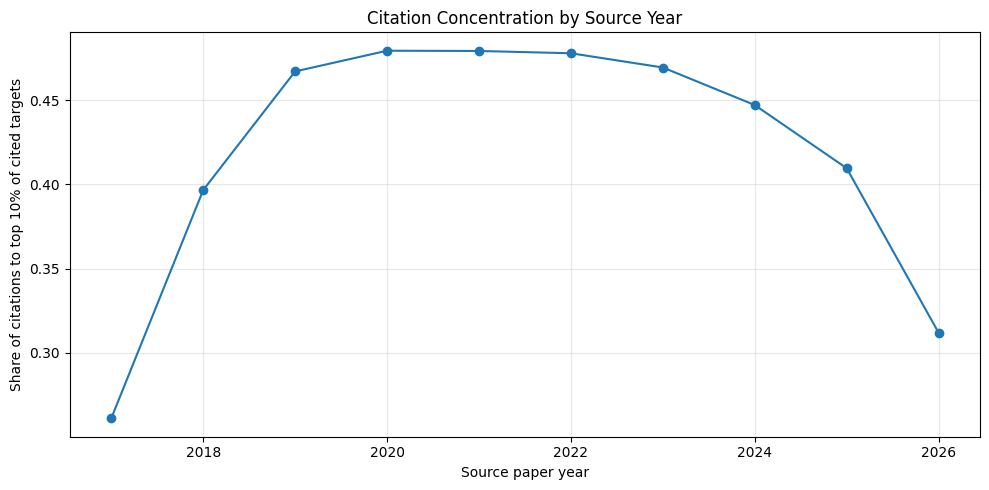

In [15]:
def top_share(group, top_frac=0.1):
    counts = group["target_paper_id"].value_counts().sort_values(ascending=False)
    k = max(1, int(np.ceil(len(counts) * top_frac)))
    return counts.iloc[:k].sum() / counts.sum()

top10_share_by_year = (
    citation_years_clean.groupby("source_year")
    .apply(lambda g: top_share(g, top_frac=0.1))
)

plt.figure(figsize=(10, 5))
plt.plot(top10_share_by_year.index, top10_share_by_year.values, marker="o")
plt.xlabel("Source paper year")
plt.ylabel("Share of citations to top 10% of cited targets")
plt.title("Citation Concentration by Source Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

If this rises after 2023, that supports concentration.

Metric 2: Citation Age Gap (core)

In [13]:
import pandas as pd

# Load
papers = pd.read_csv("paper_table_full_rich.csv")
citations = pd.read_csv("citation_fk_rich.csv")

# Keep only needed columns
papers = papers[["paper_id", "year"]].dropna()
papers["year"] = papers["year"].astype(int)

# Merge source year
df = citations.merge(
    papers.rename(columns={"paper_id": "source_paper_id", "year": "source_year"}),
    on="source_paper_id",
    how="left"
)

# Merge target year
df = df.merge(
    papers.rename(columns={"paper_id": "target_paper_id", "year": "target_year"}),
    on="target_paper_id",
    how="left"
)

# Drop missing
df = df.dropna(subset=["source_year", "target_year"])

# Compute age gap
df["age_gap"] = df["source_year"] - df["target_year"]

# Aggregate
age_gap_by_year = df.groupby("source_year")["age_gap"].mean()

print(age_gap_by_year)

source_year
2017.0    5.911243
2018.0    4.470010
2019.0    4.105725
2020.0    4.185879
2021.0    4.406898
2022.0    4.552793
2023.0    4.836115
2024.0    4.859251
2025.0    5.197120
2026.0    6.019054
Name: age_gap, dtype: float64


/var/folders/rx/ln31tkt933s4gjs2g01hxj200000gn/T/ipykernel_32635/3980205522.py:4: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  papers = pd.read_csv("paper_table_full_rich.csv")


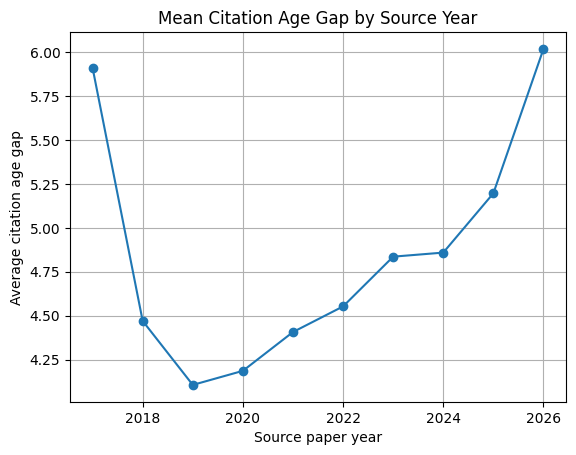

In [14]:
import matplotlib.pyplot as plt

age_gap_by_year.sort_index().plot(marker='o')
plt.title("Mean Citation Age Gap by Source Year")
plt.xlabel("Source paper year")
plt.ylabel("Average citation age gap")
plt.grid(True)
plt.show()

In [16]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ----------------------------
# 1. Load and build age-gap table
# ----------------------------
papers = pd.read_csv("paper_table_full_rich.csv")
citations = pd.read_csv("citation_fk_rich.csv")

papers = papers[["paper_id", "year"]].dropna().copy()
papers["year"] = papers["year"].astype(int)

df = citations.merge(
    papers.rename(columns={"paper_id": "source_paper_id", "year": "source_year"}),
    on="source_paper_id",
    how="left"
).merge(
    papers.rename(columns={"paper_id": "target_paper_id", "year": "target_year"}),
    on="target_paper_id",
    how="left"
)

df = df.dropna(subset=["source_year", "target_year"]).copy()
df["source_year"] = df["source_year"].astype(int)
df["target_year"] = df["target_year"].astype(int)

# citation age gap
df["age_gap"] = df["source_year"] - df["target_year"]

# optional sanity filter: remove impossible / suspicious edges
df = df[df["age_gap"] >= 0].copy()

# ----------------------------
# 2. Create piecewise-regression variables
# ----------------------------
cut = 2023

df["post2023"] = (df["source_year"] >= cut).astype(int)

# centered year helps interpretation/numerics
df["year_centered"] = df["source_year"] - cut

# interaction slope term
df["year_post_interaction"] = df["year_centered"] * df["post2023"]

# ----------------------------
# 3. Fit piecewise linear regression
# ----------------------------
model = smf.ols(
    "age_gap ~ year_centered + post2023 + year_post_interaction",
    data=df
).fit(cov_type="HC3")   # robust SEs

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                age_gap   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     180.7
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          5.21e-117
Time:                        15:20:48   Log-Likelihood:            -6.3500e+05
No. Observations:              196138   AIC:                         1.270e+06
Df Residuals:                  196134   BIC:                         1.270e+06
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.61

/var/folders/rx/ln31tkt933s4gjs2g01hxj200000gn/T/ipykernel_32635/3383792519.py:8: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  papers = pd.read_csv("paper_table_full_rich.csv")


In [17]:
print("\nKey coefficients:")
print(model.params)
print("\nP-values:")
print(model.pvalues)

b2 = model.params["post2023"]
p2 = model.pvalues["post2023"]

b3 = model.params["year_post_interaction"]
p3 = model.pvalues["year_post_interaction"]

print(f"\nLevel shift at 2023 (post2023): coef={b2:.4f}, p={p2:.4g}")
print(f"Slope change after 2023 (interaction): coef={b3:.4f}, p={p3:.4g}")


Key coefficients:
Intercept                4.614764
year_centered            0.074946
post2023                 0.141194
year_post_interaction    0.174026
dtype: float64

P-values:
Intercept                0.000000e+00
year_centered            2.667729e-04
post2023                 1.040057e-02
year_post_interaction    1.780604e-09
dtype: float64

Level shift at 2023 (post2023): coef=0.1412, p=0.0104
Slope change after 2023 (interaction): coef=0.1740, p=1.781e-09


In [18]:
model_clustered = smf.ols(
    "age_gap ~ year_centered + post2023 + year_post_interaction",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["source_paper_id"]}
)

print(model_clustered.summary())

                            OLS Regression Results                            
Dep. Variable:                age_gap   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     39.39
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           4.14e-25
Time:                        15:21:05   Log-Likelihood:            -6.3500e+05
No. Observations:              196138   AIC:                         1.270e+06
Df Residuals:                  196134   BIC:                         1.270e+06
Df Model:                           3                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.61

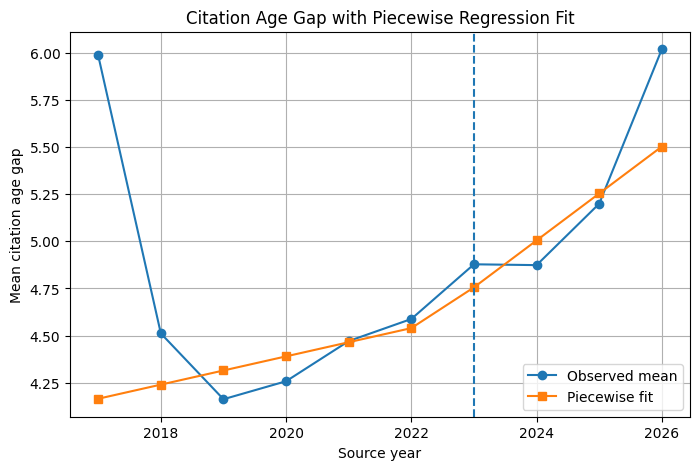

In [19]:
import matplotlib.pyplot as plt

year_means = df.groupby("source_year", as_index=False)["age_gap"].mean()

# prediction grid
grid = pd.DataFrame({"source_year": sorted(df["source_year"].unique())})
grid["post2023"] = (grid["source_year"] >= cut).astype(int)
grid["year_centered"] = grid["source_year"] - cut
grid["year_post_interaction"] = grid["year_centered"] * grid["post2023"]
grid["pred_age_gap"] = model_clustered.predict(grid)

plt.figure(figsize=(8, 5))
plt.plot(year_means["source_year"], year_means["age_gap"], marker="o", label="Observed mean")
plt.plot(grid["source_year"], grid["pred_age_gap"], marker="s", label="Piecewise fit")
plt.axvline(cut, linestyle="--")
plt.xlabel("Source year")
plt.ylabel("Mean citation age gap")
plt.title("Citation Age Gap with Piecewise Regression Fit")
plt.grid(True)
plt.legend()
plt.show()

9. Zero-reference share by year

Useful because you noticed many papers with zero refs, and this can distort everything.

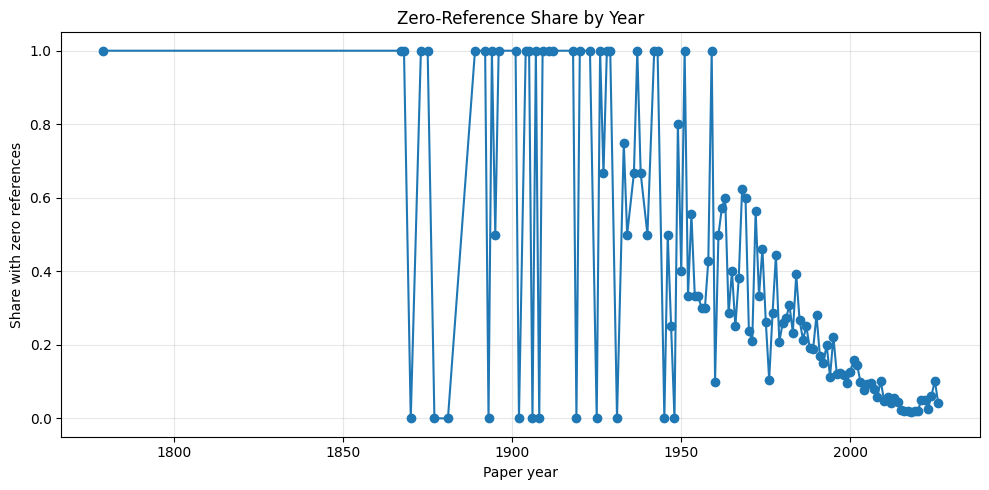

In [16]:
papers["zero_refs"] = papers["referenceCount"].fillna(0) == 0

zero_ref_share = (
    papers.dropna(subset=["year"])
          .groupby("year")["zero_refs"]
          .mean()
          .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(zero_ref_share.index, zero_ref_share.values, marker="o")
plt.xlabel("Paper year")
plt.ylabel("Share with zero references")
plt.title("Zero-Reference Share by Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

10. In-corpus reference share by source year

This asks: among all references a paper claims to have, how many point to papers that are actually inside your observed corpus?

First compute observed out-degree in your FK table.

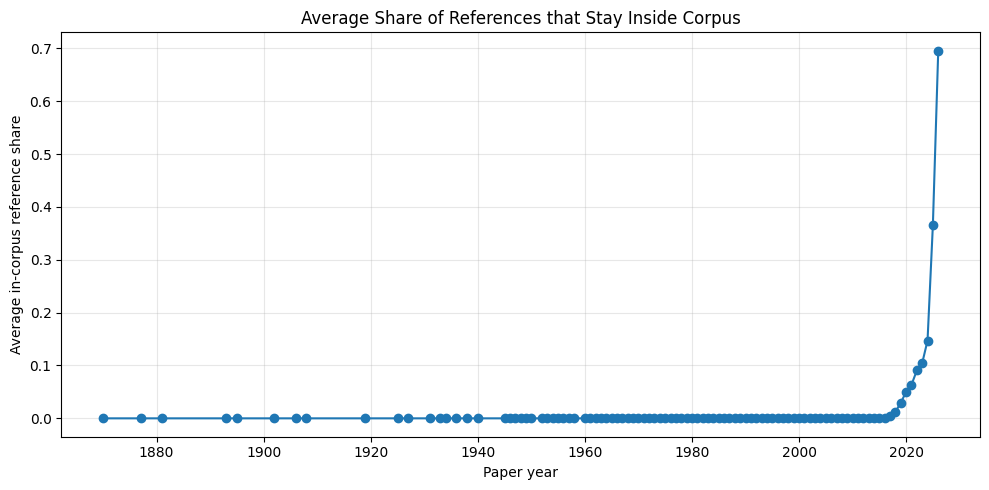

In [17]:
observed_outdeg = (
    cites.groupby("source_paper_id")
    .size()
    .reset_index(name="observed_in_corpus_refs")
)

paper_ref_compare = (
    papers[["paper_id", "year", "referenceCount"]]
    .merge(observed_outdeg, left_on="paper_id", right_on="source_paper_id", how="left")
)

paper_ref_compare["observed_in_corpus_refs"] = paper_ref_compare["observed_in_corpus_refs"].fillna(0)
paper_ref_compare["in_corpus_ref_share"] = (
    paper_ref_compare["observed_in_corpus_refs"] / paper_ref_compare["referenceCount"]
)

paper_ref_compare = paper_ref_compare.replace([np.inf, -np.inf], np.nan)

share_by_year = (
    paper_ref_compare.dropna(subset=["year", "in_corpus_ref_share"])
    .groupby("year")["in_corpus_ref_share"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(share_by_year.index, share_by_year.values, marker="o")
plt.xlabel("Paper year")
plt.ylabel("Average in-corpus reference share")
plt.title("Average Share of References that Stay Inside Corpus")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This can help distinguish “citation freezing inside the domain” from broad outward citation behavior.

11. Heatmap of source year vs target year

This is one of the best visual summaries.

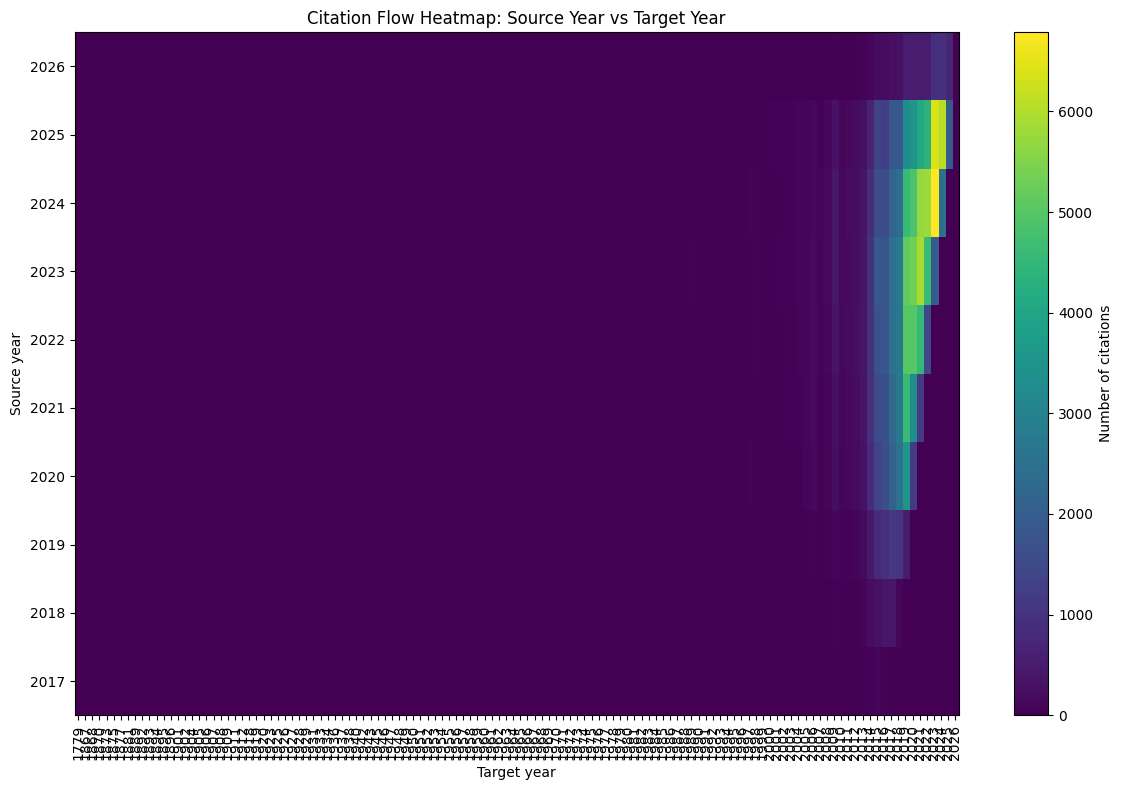

In [18]:
heat = (
    citation_years_clean.groupby(["source_year", "target_year"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 8))
plt.imshow(heat, aspect="auto", origin="lower")
plt.colorbar(label="Number of citations")
plt.xticks(
    ticks=np.arange(len(heat.columns)),
    labels=heat.columns.astype(int),
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(heat.index)),
    labels=heat.index.astype(int)
)
plt.xlabel("Target year")
plt.ylabel("Source year")
plt.title("Citation Flow Heatmap: Source Year vs Target Year")
plt.tight_layout()
plt.show()

If you want normalized rows:

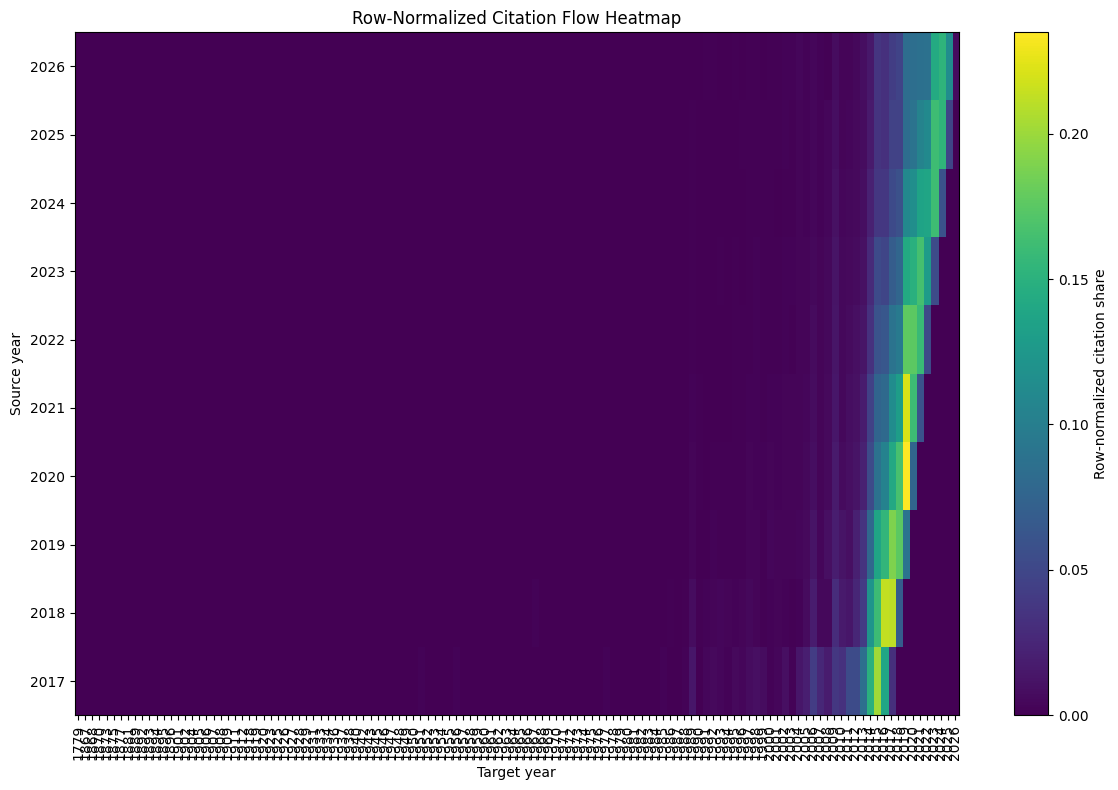

In [19]:
heat_row_norm = heat.div(heat.sum(axis=1), axis=0)

plt.figure(figsize=(12, 8))
plt.imshow(heat_row_norm, aspect="auto", origin="lower", vmin=0, vmax=heat_row_norm.max().max())
plt.colorbar(label="Row-normalized citation share")
plt.xticks(
    ticks=np.arange(len(heat_row_norm.columns)),
    labels=heat_row_norm.columns.astype(int),
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(heat_row_norm.index)),
    labels=heat_row_norm.index.astype(int)
)
plt.xlabel("Target year")
plt.ylabel("Source year")
plt.title("Row-Normalized Citation Flow Heatmap")
plt.tight_layout()
plt.show()

12. A single reusable function for pre/post comparison

This is handy if you want quick comparisons.

In [20]:
def compare_pre_post(series_by_year, split_year=2023, ylabel="", title=""):
    s = series_by_year.dropna()
    pre = s[s.index < split_year]
    post = s[s.index >= split_year]

    plt.figure(figsize=(10, 5))
    plt.plot(s.index, s.values, marker="o")
    plt.axvline(split_year - 0.5, linestyle="--")
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Pre mean:", pre.mean())
    print("Post mean:", post.mean())

Example use:

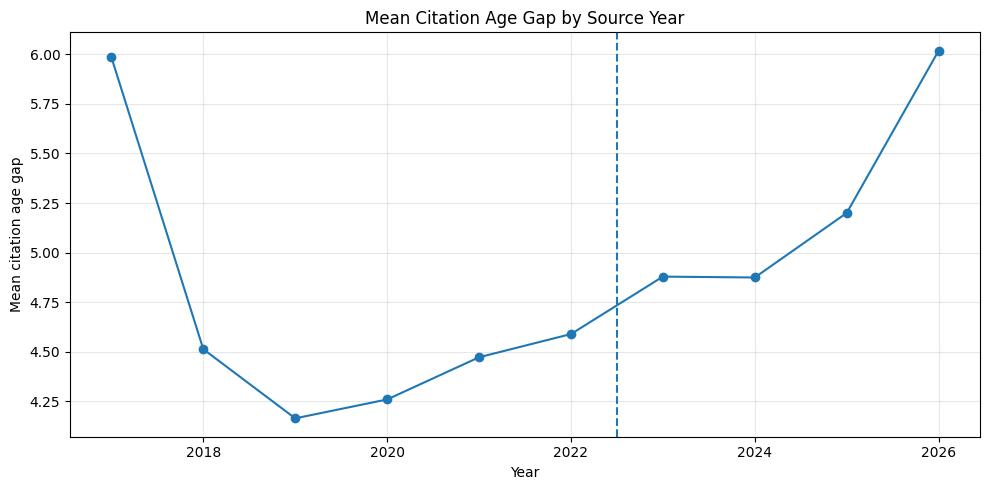

Pre mean: 4.662905239802467
Post mean: 5.242734521910469


In [21]:
compare_pre_post(
    mean_age_by_source_year,
    split_year=2023,
    ylabel="Mean citation age gap",
    title="Mean Citation Age Gap by Source Year"
)

The most important 5 plots to run first

If you do not want everything, run these first:

In [22]:
# 1
# papers per year

# 2
# average references per paper by year

# 3
# mean citation age by source year

# 4
# share of citations to papers at least 5/10 years older

# 5
# citation concentration by source year

A practical note

Because your corpus has many zero-reference papers and possibly incomplete Semantic Scholar reference coverage, interpret these carefully:

referenceCount from paper metadata may be more complete than in-corpus FK links.
citation_fk_rich.csv only reflects references you successfully resolved into your internal paper table.
So age-gap plots on FK data are about resolved in-corpus citations, not necessarily all citations the paper made.

That distinction matters a lot.

If you want, I can next give you one clean end-to-end script that generates all these plots and saves them into a plots/ folder automatically.

/var/folders/rx/ln31tkt933s4gjs2g01hxj200000gn/T/ipykernel_39716/498603715.py:9: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  papers = pd.read_csv("paper_table_full_rich.csv")


Number of usable citation edges:
pre-2023: 73490
post-2023: 123693

Paper-level mean citation age gap summary:
pre-2023 mean: 4.460396304841025
post-2023 mean: 5.16763031496674
pre-2023 median: 4.181818181818182
post-2023 median: 4.91925925925926


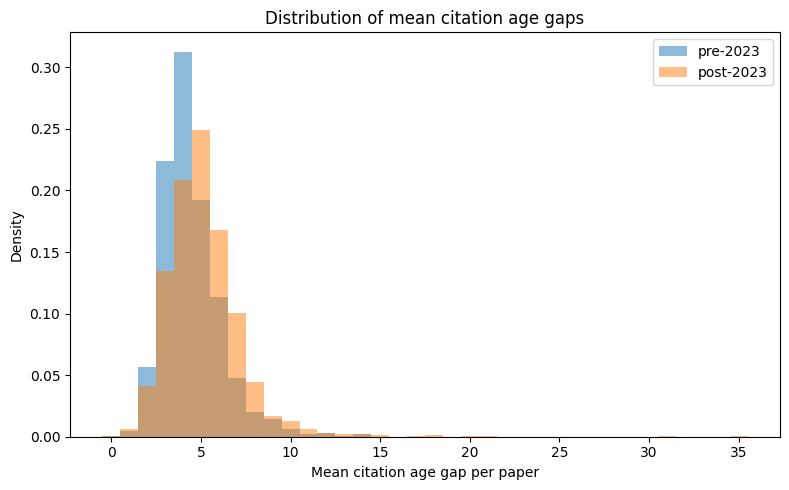

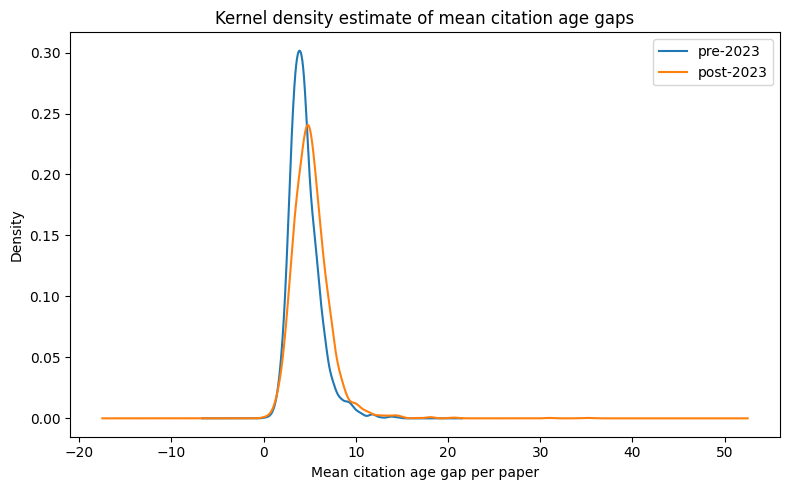


One-sided Mann–Whitney U test
H0: post-2023 distribution is not shifted to larger values
H1: post-2023 distribution is shifted to larger values
U statistic: 2727291.5
p-value: 7.208894096593034e-40

One-sided KS test
KS statistic: 0.0052694101748114565
p-value: 0.9406006308483198

Citation concentration (Gini over cited-paper frequencies)
pre-2023 Gini: 0.5833721684397467
post-2023 Gini: 0.5195103061190541

Top-k citation share
Top-10 share, pre-2023:  0.0687
Top-10 share, post-2023: 0.0457
Top-50 share, pre-2023:  0.1552
Top-50 share, post-2023: 0.1032
Top-100 share, pre-2023:  0.2084
Top-100 share, post-2023: 0.1416

Reference count summary
pre-2023 mean: 48.53867717251307
post-2023 mean: 55.966900803476676
pre-2023 median: 41.0
post-2023 median: 50.0


/Users/bolongtang/.pyenv/versions/3.13.2/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


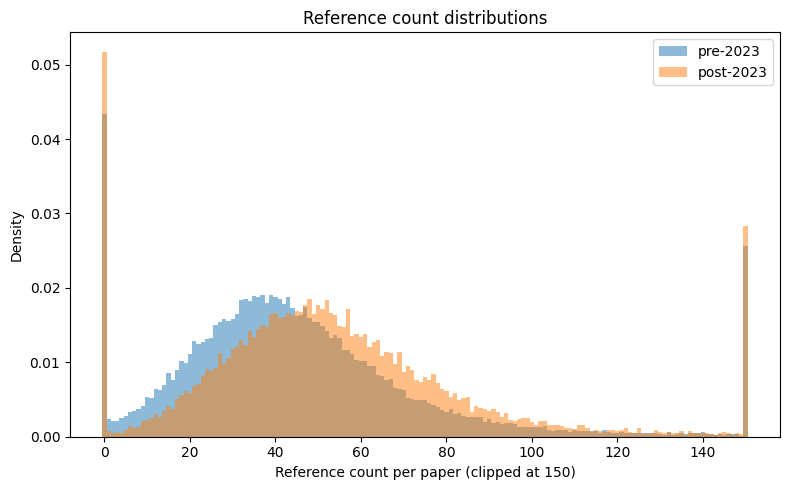


Reference count Mann–Whitney U test (two-sided)
U statistic: 615435051.0
p-value: 6.11347301209206e-300

Robustness check: only source papers with nonzero references and valid metadata
Robust pre mean gap: 4.46333383500004
Robust post mean gap: 5.166324132953559
Robust Mann–Whitney U statistic: 2607869.5
Robust Mann–Whitney p-value: 8.574150325591951e-39
Robust pre Gini: 0.5832865634149439
Robust post Gini: 0.5164564573023367


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ks_2samp

# =========================
# 1. Load data
# =========================
papers = pd.read_csv("paper_table_full_rich.csv")
citations = pd.read_csv("citation_fk_rich.csv")

# Keep only needed columns
papers = papers[["paper_id", "year", "referenceCount", "title"]].copy()

# Clean types
papers["paper_id"] = pd.to_numeric(papers["paper_id"], errors="coerce")
papers["year"] = pd.to_numeric(papers["year"], errors="coerce")
papers["referenceCount"] = pd.to_numeric(papers["referenceCount"], errors="coerce")

citations["source_paper_id"] = pd.to_numeric(citations["source_paper_id"], errors="coerce")
citations["target_paper_id"] = pd.to_numeric(citations["target_paper_id"], errors="coerce")

papers = papers.dropna(subset=["paper_id", "year"])
citations = citations.dropna(subset=["source_paper_id", "target_paper_id"])

papers["paper_id"] = papers["paper_id"].astype(int)
citations["source_paper_id"] = citations["source_paper_id"].astype(int)
citations["target_paper_id"] = citations["target_paper_id"].astype(int)

# =========================
# 2. Merge citation edges with source/target year
# =========================
paper_year_map = papers.set_index("paper_id")["year"]

edge_df = citations.copy()
edge_df["source_year"] = edge_df["source_paper_id"].map(paper_year_map)
edge_df["target_year"] = edge_df["target_paper_id"].map(paper_year_map)

# Keep only edges with both years known
edge_df = edge_df.dropna(subset=["source_year", "target_year"]).copy()

edge_df["source_year"] = edge_df["source_year"].astype(int)
edge_df["target_year"] = edge_df["target_year"].astype(int)

# Citation age gap = citing year - cited year
edge_df["citation_age_gap"] = edge_df["source_year"] - edge_df["target_year"]

# Optional sanity filter: remove impossible negative gaps if desired
# edge_df = edge_df[edge_df["citation_age_gap"] >= 0].copy()

# =========================
# 3. Split into pre-2023 and post-2023
#    You can change this if you want 2023 included elsewhere
# =========================
pre_edges = edge_df[edge_df["source_year"] < 2023].copy()
post_edges = edge_df[edge_df["source_year"] >= 2023].copy()

print("Number of usable citation edges:")
print("pre-2023:", len(pre_edges))
print("post-2023:", len(post_edges))

# =========================
# 4. Paper-level mean citation age gap
#    (more appropriate than treating every edge as independent)
# =========================
paper_gap = (
    edge_df.groupby("source_paper_id", as_index=False)["citation_age_gap"]
    .mean()
    .rename(columns={"citation_age_gap": "mean_citation_age_gap"})
)

paper_gap["source_year"] = paper_gap["source_paper_id"].map(paper_year_map)
paper_gap = paper_gap.dropna(subset=["source_year"]).copy()
paper_gap["source_year"] = paper_gap["source_year"].astype(int)

pre_paper_gap = paper_gap.loc[
    paper_gap["source_year"] < 2023, "mean_citation_age_gap"
].dropna()

post_paper_gap = paper_gap.loc[
    paper_gap["source_year"] >= 2023, "mean_citation_age_gap"
].dropna()

print("\nPaper-level mean citation age gap summary:")
print("pre-2023 mean:", pre_paper_gap.mean())
print("post-2023 mean:", post_paper_gap.mean())
print("pre-2023 median:", pre_paper_gap.median())
print("post-2023 median:", post_paper_gap.median())

# =========================
# 5. Histogram plot
# =========================
plt.figure(figsize=(8, 5))
bins = np.arange(
    int(min(pre_paper_gap.min(), post_paper_gap.min())),
    int(max(pre_paper_gap.max(), post_paper_gap.max())) + 2
) - 0.5

plt.hist(pre_paper_gap, bins=bins, alpha=0.5, density=True, label="pre-2023")
plt.hist(post_paper_gap, bins=bins, alpha=0.5, density=True, label="post-2023")
plt.xlabel("Mean citation age gap per paper")
plt.ylabel("Density")
plt.title("Distribution of mean citation age gaps")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 6. Simple KDE (manual, via pandas plot density)
#    Avoids seaborn
# =========================
plt.figure(figsize=(8, 5))
pre_paper_gap.plot(kind="density", label="pre-2023")
post_paper_gap.plot(kind="density", label="post-2023")
plt.xlabel("Mean citation age gap per paper")
plt.title("Kernel density estimate of mean citation age gaps")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 7. One-sided Mann–Whitney U test
#    H1: post-2023 > pre-2023
# =========================
mw_stat, mw_p = mannwhitneyu(
    post_paper_gap,
    pre_paper_gap,
    alternative="greater"
)

print("\nOne-sided Mann–Whitney U test")
print("H0: post-2023 distribution is not shifted to larger values")
print("H1: post-2023 distribution is shifted to larger values")
print("U statistic:", mw_stat)
print("p-value:", mw_p)

# Optional KS test too
ks_stat, ks_p = ks_2samp(post_paper_gap, pre_paper_gap, alternative="greater")
print("\nOne-sided KS test")
print("KS statistic:", ks_stat)
print("p-value:", ks_p)

# =========================
# 8. Gini coefficient over cited-paper frequencies
# =========================
def gini(array):
    """
    Gini coefficient for a nonnegative 1D array.
    """
    x = np.asarray(array, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan
    if np.any(x < 0):
        raise ValueError("Gini requires nonnegative values.")
    if np.all(x == 0):
        return 0.0

    x_sorted = np.sort(x)
    n = len(x_sorted)
    cumx = np.cumsum(x_sorted)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

# Count how often each target paper is cited within each subset
pre_target_counts = pre_edges["target_paper_id"].value_counts().values
post_target_counts = post_edges["target_paper_id"].value_counts().values

pre_gini = gini(pre_target_counts)
post_gini = gini(post_target_counts)

print("\nCitation concentration (Gini over cited-paper frequencies)")
print("pre-2023 Gini:", pre_gini)
print("post-2023 Gini:", post_gini)

# Optional top-k share
def top_k_share(counts, k=10):
    counts = np.asarray(counts, dtype=float)
    if len(counts) == 0:
        return np.nan
    counts = np.sort(counts)[::-1]
    return counts[:k].sum() / counts.sum()

print("\nTop-k citation share")
for k in [10, 50, 100]:
    print(f"Top-{k} share, pre-2023:  {top_k_share(pre_target_counts, k):.4f}")
    print(f"Top-{k} share, post-2023: {top_k_share(post_target_counts, k):.4f}")

# =========================
# 9. Reference count distributions
# =========================
paper_with_refs = papers.copy()

pre_papers = paper_with_refs[paper_with_refs["year"] < 2023].copy()
post_papers = paper_with_refs[paper_with_refs["year"] >= 2023].copy()

pre_ref = pre_papers["referenceCount"].dropna()
post_ref = post_papers["referenceCount"].dropna()

print("\nReference count summary")
print("pre-2023 mean:", pre_ref.mean())
print("post-2023 mean:", post_ref.mean())
print("pre-2023 median:", pre_ref.median())
print("post-2023 median:", post_ref.median())

plt.figure(figsize=(8, 5))
bins = np.arange(
    0,
    int(min(max(pre_ref.max(), post_ref.max()), 150)) + 2
) - 0.5

plt.hist(pre_ref.clip(upper=150), bins=bins, alpha=0.5, density=True, label="pre-2023")
plt.hist(post_ref.clip(upper=150), bins=bins, alpha=0.5, density=True, label="post-2023")
plt.xlabel("Reference count per paper (clipped at 150)")
plt.ylabel("Density")
plt.title("Reference count distributions")
plt.legend()
plt.tight_layout()
plt.show()

mw_ref_stat, mw_ref_p = mannwhitneyu(post_ref, pre_ref, alternative="two-sided")
print("\nReference count Mann–Whitney U test (two-sided)")
print("U statistic:", mw_ref_stat)
print("p-value:", mw_ref_p)

# =========================
# 10. Robustness checks:
#     restrict to papers with nonzero references and valid metadata
# =========================
valid_paper_ids = set(
    papers.loc[
        papers["year"].notna() &
        papers["referenceCount"].notna() &
        (papers["referenceCount"] > 0),
        "paper_id"
    ]
)

robust_edges = edge_df[
    edge_df["source_paper_id"].isin(valid_paper_ids) &
    edge_df["target_paper_id"].isin(set(papers["paper_id"]))
].copy()

robust_paper_gap = (
    robust_edges.groupby("source_paper_id", as_index=False)["citation_age_gap"]
    .mean()
    .rename(columns={"citation_age_gap": "mean_citation_age_gap"})
)

robust_paper_gap["source_year"] = robust_paper_gap["source_paper_id"].map(paper_year_map)
robust_paper_gap = robust_paper_gap.dropna(subset=["source_year"]).copy()
robust_paper_gap["source_year"] = robust_paper_gap["source_year"].astype(int)

robust_pre = robust_paper_gap.loc[
    robust_paper_gap["source_year"] < 2023, "mean_citation_age_gap"
].dropna()

robust_post = robust_paper_gap.loc[
    robust_paper_gap["source_year"] >= 2023, "mean_citation_age_gap"
].dropna()

mw_robust_stat, mw_robust_p = mannwhitneyu(
    robust_post,
    robust_pre,
    alternative="greater"
)

robust_pre_edges = robust_edges[robust_edges["source_year"] < 2023]
robust_post_edges = robust_edges[robust_edges["source_year"] >= 2023]

robust_pre_target_counts = robust_pre_edges["target_paper_id"].value_counts().values
robust_post_target_counts = robust_post_edges["target_paper_id"].value_counts().values

print("\nRobustness check: only source papers with nonzero references and valid metadata")
print("Robust pre mean gap:", robust_pre.mean())
print("Robust post mean gap:", robust_post.mean())
print("Robust Mann–Whitney U statistic:", mw_robust_stat)
print("Robust Mann–Whitney p-value:", mw_robust_p)
print("Robust pre Gini:", gini(robust_pre_target_counts))
print("Robust post Gini:", gini(robust_post_target_counts))

In [2]:
results_table = pd.DataFrame({
    "metric": [
        "Mean citation age gap (pre-2023)",
        "Mean citation age gap (post-2023)",
        "Median citation age gap (pre-2023)",
        "Median citation age gap (post-2023)",
        "Mann-Whitney U p-value (one-sided)",
        "KS p-value (one-sided)",
        "Gini of cited-paper frequencies (pre-2023)",
        "Gini of cited-paper frequencies (post-2023)",
        "Mean reference count (pre-2023)",
        "Mean reference count (post-2023)",
        "Reference count MW p-value (two-sided)",
    ],
    "value": [
        pre_paper_gap.mean(),
        post_paper_gap.mean(),
        pre_paper_gap.median(),
        post_paper_gap.median(),
        mw_p,
        ks_p,
        pre_gini,
        post_gini,
        pre_ref.mean(),
        post_ref.mean(),
        mw_ref_p,
    ]
})

print(results_table)
results_table.to_csv("citation_shift_results_table.csv", index=False)

                                         metric          value
0              Mean citation age gap (pre-2023)   4.460396e+00
1             Mean citation age gap (post-2023)   5.167630e+00
2            Median citation age gap (pre-2023)   4.181818e+00
3           Median citation age gap (post-2023)   4.919259e+00
4            Mann-Whitney U p-value (one-sided)   7.208894e-40
5                        KS p-value (one-sided)   9.406006e-01
6    Gini of cited-paper frequencies (pre-2023)   5.833722e-01
7   Gini of cited-paper frequencies (post-2023)   5.195103e-01
8               Mean reference count (pre-2023)   4.853868e+01
9              Mean reference count (post-2023)   5.596690e+01
10       Reference count MW p-value (two-sided)  6.113473e-300


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ks_2samp

# =====================================
# Configuration
# =====================================
PAPER_CSV = "paper_table_full_rich.csv"
CITATION_CSV = "citation_fk_rich.csv"
OUTDIR = "neurips_outputs"
os.makedirs(OUTDIR, exist_ok=True)

PRE_LABEL = "Pre-2023"
POST_LABEL = "Post-2023"
YEAR_SPLIT = 2023

# =====================================
# Helpers
# =====================================
def gini(array):
    x = np.asarray(array, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan
    if np.any(x < 0):
        raise ValueError("Gini requires nonnegative values.")
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

def top_k_share(counts, k):
    counts = np.asarray(counts, dtype=float)
    if len(counts) == 0:
        return np.nan
    counts = np.sort(counts)[::-1]
    return counts[:k].sum() / counts.sum()

def save_current_figure(stem):
    pdf_path = os.path.join(OUTDIR, f"{stem}.pdf")
    png_path = os.path.join(OUTDIR, f"{stem}.png")
    plt.tight_layout()
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

def safe_mean(x):
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    return float(np.median(x)) if len(x) else np.nan

# =====================================
# Load and clean data
# =====================================
papers = pd.read_csv(PAPER_CSV)
citations = pd.read_csv(CITATION_CSV)

paper_cols = ["paper_id", "year", "referenceCount", "title"]
papers = papers[[c for c in paper_cols if c in papers.columns]].copy()

papers["paper_id"] = pd.to_numeric(papers["paper_id"], errors="coerce")
papers["year"] = pd.to_numeric(papers["year"], errors="coerce")
papers["referenceCount"] = pd.to_numeric(papers["referenceCount"], errors="coerce")

citations["source_paper_id"] = pd.to_numeric(citations["source_paper_id"], errors="coerce")
citations["target_paper_id"] = pd.to_numeric(citations["target_paper_id"], errors="coerce")

papers = papers.dropna(subset=["paper_id", "year"]).copy()
citations = citations.dropna(subset=["source_paper_id", "target_paper_id"]).copy()

papers["paper_id"] = papers["paper_id"].astype(int)
papers["year"] = papers["year"].astype(int)
citations["source_paper_id"] = citations["source_paper_id"].astype(int)
citations["target_paper_id"] = citations["target_paper_id"].astype(int)

paper_year_map = papers.set_index("paper_id")["year"]
paper_refcount_map = papers.set_index("paper_id")["referenceCount"]

# =====================================
# Edge table with years
# =====================================
edge_df = citations.copy()
edge_df["source_year"] = edge_df["source_paper_id"].map(paper_year_map)
edge_df["target_year"] = edge_df["target_paper_id"].map(paper_year_map)
edge_df = edge_df.dropna(subset=["source_year", "target_year"]).copy()

edge_df["source_year"] = edge_df["source_year"].astype(int)
edge_df["target_year"] = edge_df["target_year"].astype(int)
edge_df["citation_age_gap"] = edge_df["source_year"] - edge_df["target_year"]

# Optional filter if you want only nonnegative time gaps
edge_df = edge_df[edge_df["citation_age_gap"] >= 0].copy()

pre_edges = edge_df[edge_df["source_year"] < YEAR_SPLIT].copy()
post_edges = edge_df[edge_df["source_year"] >= YEAR_SPLIT].copy()

# =====================================
# Paper-level mean citation age gap
# =====================================
paper_gap = (
    edge_df.groupby("source_paper_id", as_index=False)["citation_age_gap"]
    .mean()
    .rename(columns={"citation_age_gap": "mean_citation_age_gap"})
)
paper_gap["source_year"] = paper_gap["source_paper_id"].map(paper_year_map)
paper_gap["referenceCount"] = paper_gap["source_paper_id"].map(paper_refcount_map)
paper_gap = paper_gap.dropna(subset=["source_year"]).copy()
paper_gap["source_year"] = paper_gap["source_year"].astype(int)

pre_paper_gap = paper_gap.loc[
    paper_gap["source_year"] < YEAR_SPLIT, "mean_citation_age_gap"
].dropna().to_numpy()

post_paper_gap = paper_gap.loc[
    paper_gap["source_year"] >= YEAR_SPLIT, "mean_citation_age_gap"
].dropna().to_numpy()

# =====================================
# Tests: citation age gap
# H1: post > pre
# =====================================
mw_gap_stat, mw_gap_p = mannwhitneyu(post_paper_gap, pre_paper_gap, alternative="greater")
ks_gap_stat, ks_gap_p = ks_2samp(post_paper_gap, pre_paper_gap, alternative="greater")

# =====================================
# Gini over cited-paper frequencies
# =====================================
pre_target_counts = pre_edges["target_paper_id"].value_counts().values
post_target_counts = post_edges["target_paper_id"].value_counts().values

pre_gini = gini(pre_target_counts)
post_gini = gini(post_target_counts)

pre_top10 = top_k_share(pre_target_counts, 10)
post_top10 = top_k_share(post_target_counts, 10)
pre_top50 = top_k_share(pre_target_counts, 50)
post_top50 = top_k_share(post_target_counts, 50)

# =====================================
# Reference count control
# =====================================
pre_ref = papers.loc[papers["year"] < YEAR_SPLIT, "referenceCount"].dropna().to_numpy()
post_ref = papers.loc[papers["year"] >= YEAR_SPLIT, "referenceCount"].dropna().to_numpy()

mw_ref_stat, mw_ref_p = mannwhitneyu(post_ref, pre_ref, alternative="two-sided")
ks_ref_stat, ks_ref_p = ks_2samp(post_ref, pre_ref, alternative="two-sided")

# =====================================
# Robustness: source papers with nonzero refs and valid metadata
# =====================================
valid_source_ids = set(
    papers.loc[
        papers["year"].notna() &
        papers["referenceCount"].notna() &
        (papers["referenceCount"] > 0),
        "paper_id"
    ].astype(int)
)

robust_edges = edge_df[edge_df["source_paper_id"].isin(valid_source_ids)].copy()

robust_paper_gap = (
    robust_edges.groupby("source_paper_id", as_index=False)["citation_age_gap"]
    .mean()
    .rename(columns={"citation_age_gap": "mean_citation_age_gap"})
)
robust_paper_gap["source_year"] = robust_paper_gap["source_paper_id"].map(paper_year_map)
robust_paper_gap = robust_paper_gap.dropna(subset=["source_year"]).copy()
robust_paper_gap["source_year"] = robust_paper_gap["source_year"].astype(int)

robust_pre = robust_paper_gap.loc[
    robust_paper_gap["source_year"] < YEAR_SPLIT, "mean_citation_age_gap"
].dropna().to_numpy()

robust_post = robust_paper_gap.loc[
    robust_paper_gap["source_year"] >= YEAR_SPLIT, "mean_citation_age_gap"
].dropna().to_numpy()

mw_robust_stat, mw_robust_p = mannwhitneyu(robust_post, robust_pre, alternative="greater")
ks_robust_stat, ks_robust_p = ks_2samp(robust_post, robust_pre, alternative="greater")

robust_pre_target_counts = robust_edges.loc[
    robust_edges["source_year"] < YEAR_SPLIT, "target_paper_id"
].value_counts().values
robust_post_target_counts = robust_edges.loc[
    robust_edges["source_year"] >= YEAR_SPLIT, "target_paper_id"
].value_counts().values

robust_pre_gini = gini(robust_pre_target_counts)
robust_post_gini = gini(robust_post_target_counts)

# =====================================
# Figure 1: Histogram of mean citation age gap
# =====================================
plt.figure(figsize=(6.8, 4.6))
min_gap = min(np.min(pre_paper_gap), np.min(post_paper_gap))
max_gap = max(np.max(pre_paper_gap), np.max(post_paper_gap))
bins = np.arange(np.floor(min_gap), np.ceil(max_gap) + 1.0, 1.0)

plt.hist(pre_paper_gap, bins=bins, density=True, alpha=0.5, label=PRE_LABEL)
plt.hist(post_paper_gap, bins=bins, density=True, alpha=0.5, label=POST_LABEL)
plt.xlabel("Mean citation age gap per paper")
plt.ylabel("Density")
plt.title("Citation age gap distribution")
plt.legend(frameon=False)
save_current_figure("fig_citation_age_gap_hist")
plt.close()

# =====================================
# Figure 2: KDE-style density plot
# =====================================
plt.figure(figsize=(6.8, 4.6))
pd.Series(pre_paper_gap).plot(kind="density", label=PRE_LABEL)
pd.Series(post_paper_gap).plot(kind="density", label=POST_LABEL)
plt.xlabel("Mean citation age gap per paper")
plt.ylabel("Density")
plt.title("Citation age gap density")
plt.legend(frameon=False)
save_current_figure("fig_citation_age_gap_kde")
plt.close()

# =====================================
# Figure 3: Reference count histogram
# =====================================
plt.figure(figsize=(6.8, 4.6))
clip_max = 150
pre_ref_clip = np.clip(pre_ref, None, clip_max)
post_ref_clip = np.clip(post_ref, None, clip_max)
bins = np.arange(0, clip_max + 2) - 0.5

plt.hist(pre_ref_clip, bins=bins, density=True, alpha=0.5, label=PRE_LABEL)
plt.hist(post_ref_clip, bins=bins, density=True, alpha=0.5, label=POST_LABEL)
plt.xlabel(f"Reference count per paper (clipped at {clip_max})")
plt.ylabel("Density")
plt.title("Reference count distribution")
plt.legend(frameon=False)
save_current_figure("fig_reference_count_hist")
plt.close()

# =====================================
# Figure 4: Citation concentration bar chart
# =====================================
plt.figure(figsize=(5.6, 4.2))
plt.bar([PRE_LABEL, POST_LABEL], [pre_gini, post_gini])
plt.ylabel("Gini coefficient")
plt.title("Citation concentration")
save_current_figure("fig_gini_bar")
plt.close()

# =====================================
# Results table
# =====================================
results = pd.DataFrame({
    "Metric": [
        "N usable citation edges",
        "N source papers with mean age gap",
        "Mean citation age gap",
        "Median citation age gap",
        "MW U p-value (one-sided, post > pre)",
        "KS p-value (one-sided, post > pre)",
        "Gini of cited-paper frequencies",
        "Top-10 citation share",
        "Top-50 citation share",
        "Mean reference count",
        "Median reference count",
        "MW U p-value for reference count (two-sided)",
        "KS p-value for reference count (two-sided)",
        "Robust mean citation age gap",
        "Robust median citation age gap",
        "Robust MW U p-value (one-sided, post > pre)",
        "Robust KS p-value (one-sided, post > pre)",
        "Robust Gini of cited-paper frequencies",
    ],
    PRE_LABEL: [
        len(pre_edges),
        len(pre_paper_gap),
        safe_mean(pre_paper_gap),
        safe_median(pre_paper_gap),
        np.nan,
        np.nan,
        pre_gini,
        pre_top10,
        pre_top50,
        safe_mean(pre_ref),
        safe_median(pre_ref),
        np.nan,
        np.nan,
        safe_mean(robust_pre),
        safe_median(robust_pre),
        np.nan,
        np.nan,
        robust_pre_gini,
    ],
    POST_LABEL: [
        len(post_edges),
        len(post_paper_gap),
        safe_mean(post_paper_gap),
        safe_median(post_paper_gap),
        mw_gap_p,
        ks_gap_p,
        post_gini,
        post_top10,
        post_top50,
        safe_mean(post_ref),
        safe_median(post_ref),
        mw_ref_p,
        ks_ref_p,
        safe_mean(robust_post),
        safe_median(robust_post),
        mw_robust_p,
        ks_robust_p,
        robust_post_gini,
    ]
})

csv_path = os.path.join(OUTDIR, "main_results_table.csv")
results.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# =====================================
# Write LaTeX table
# =====================================
def fmt(x):
    if pd.isna(x):
        return "--"
    if isinstance(x, (int, np.integer)):
        return f"{x:d}"
    if abs(float(x)) >= 1000:
        return f"{float(x):.2f}"
    if 0 < abs(float(x)) < 1e-3:
        return f"{float(x):.2e}"
    return f"{float(x):.4f}"

latex_lines = []
latex_lines.append(r"\begin{table}[t]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Main comparison between pre-2023 and post-2023 subsets. For hypothesis tests, the reported $p$-values correspond to the alternative that post-2023 papers exhibit larger citation age gaps.}")
latex_lines.append(r"\label{tab:main_results}")
latex_lines.append(r"\begin{tabular}{lcc}")
latex_lines.append(r"\toprule")
latex_lines.append(r"Metric & Pre-2023 & Post-2023 \\")
latex_lines.append(r"\midrule")

for _, row in results.iterrows():
    metric = str(row["Metric"]).replace("&", r"\&")
    pre_val = fmt(row[PRE_LABEL])
    post_val = fmt(row[POST_LABEL])
    latex_lines.append(f"{metric} & {pre_val} & {post_val} \\\\")

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\end{table}")

latex_table = "\n".join(latex_lines)
tex_path = os.path.join(OUTDIR, "main_results_table.tex")
with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex_table)

print(f"Saved: {tex_path}")

# =====================================
# Console summary
# =====================================
print("\n=== Main results summary ===")
print(f"Mean citation age gap: {PRE_LABEL}={safe_mean(pre_paper_gap):.4f}, {POST_LABEL}={safe_mean(post_paper_gap):.4f}")
print(f"Median citation age gap: {PRE_LABEL}={safe_median(pre_paper_gap):.4f}, {POST_LABEL}={safe_median(post_paper_gap):.4f}")
print(f"One-sided MW p-value (post > pre): {mw_gap_p:.6g}")
print(f"One-sided KS p-value (post > pre): {ks_gap_p:.6g}")
print(f"Gini: {PRE_LABEL}={pre_gini:.4f}, {POST_LABEL}={post_gini:.4f}")
print(f"Reference count mean: {PRE_LABEL}={safe_mean(pre_ref):.4f}, {POST_LABEL}={safe_mean(post_ref):.4f}")
print(f"Reference count MW p-value: {mw_ref_p:.6g}")
print(f"Robust MW p-value (post > pre): {mw_robust_p:.6g}")
print(f"Robust Gini: {PRE_LABEL}={robust_pre_gini:.4f}, {POST_LABEL}={robust_post_gini:.4f}")

/var/folders/rx/ln31tkt933s4gjs2g01hxj200000gn/T/ipykernel_39716/651742879.py:61: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  papers = pd.read_csv(PAPER_CSV)
/Users/bolongtang/.pyenv/versions/3.13.2/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/Users/bolongtang/.pyenv/versions/3.13.2/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Saved: neurips_outputs/fig_citation_age_gap_hist.pdf
Saved: neurips_outputs/fig_citation_age_gap_hist.png
Saved: neurips_outputs/fig_citation_age_gap_kde.pdf
Saved: neurips_outputs/fig_citation_age_gap_kde.png
Saved: neurips_outputs/fig_reference_count_hist.pdf
Saved: neurips_outputs/fig_reference_count_hist.png
Saved: neurips_outputs/fig_gini_bar.pdf
Saved: neurips_outputs/fig_gini_bar.png
Saved: neurips_outputs/main_results_table.csv
Saved: neurips_outputs/main_results_table.tex

=== Main results summary ===
Mean citation age gap: Pre-2023=4.4948, Post-2023=5.1804
Median citation age gap: Pre-2023=4.2275, Post-2023=4.9408
One-sided MW p-value (post > pre): 3.6826e-38
One-sided KS p-value (post > pre): 0.892988
Gini: Pre-2023=0.5858, Post-2023=0.5202
Reference count mean: Pre-2023=48.5387, Post-2023=55.9669
Reference count MW p-value: 6.11347e-300
Robust MW p-value (post > pre): 3.21446e-37
Robust Gini: Pre-2023=0.5856, Post-2023=0.5172
